В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
train_df = pd.read_csv('train.csv')

train_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
train_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [4]:
X = train_df.drop('Exited', axis=1)
y = train_df['Exited']

X.shape, y.shape

((15000, 13), (15000,))

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((12000, 13), (3000, 13), (12000,), (3000,))

In [6]:
print("y full:")
print(y.value_counts(normalize=True))

print("\ny_train:")
print(y_train.value_counts(normalize=True))

print("\ny_val:")
print(y_val.value_counts(normalize=True))

y full:
Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

y_train:
Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64

y_val:
Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


Дані було розбито на train та validation піднабори у співвідношенні 80/20. Для розбиття використано `stratify=y`, щоб зберегти однакову пропорцію класів `Exited = 0` та `Exited = 1` у train і validation. Перевірка показала, що частки класів у повному датасеті, train та validation майже однакові.

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [7]:
target_col = 'Exited'

input_cols = list(X_train.columns)

train_inputs = X_train[input_cols].copy()
train_targets = y_train.copy()

val_inputs = X_val[input_cols].copy()
val_targets = y_val.copy()

train_inputs.shape, train_targets.shape, val_inputs.shape, val_targets.shape

((12000, 13), (12000,), (3000, 13), (3000,))

Було визначено цільову колонку `Exited` та список вхідних колонок `input_cols`. На основі цих колонок створено окремі набори `train_inputs`, `train_targets`, `val_inputs`, `val_targets` для тренувального та валідаційного піднаборів.

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [8]:
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Categorical columns:
['Surname', 'Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [9]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Видаляємо колонки, які не будемо використовувати в моделі
drop_cols = ['id', 'CustomerId', 'Surname']

train_inputs = train_inputs.drop(columns=drop_cols)
val_inputs = val_inputs.drop(columns=drop_cols)

# Оновлюємо списки числових і категоріальних колонок
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object']).columns.tolist()

# Заповнення пропущених значень у числових колонках медіаною
num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = num_imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = num_imputer.transform(val_inputs[numeric_cols])

# Масштабування числових колонок
scaler = StandardScaler()
scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

# Кодування категоріальних колонок
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_inputs[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)

train_encoded = pd.DataFrame(
    encoder.transform(train_inputs[categorical_cols]),
    columns=encoded_cols,
    index=train_inputs.index
)

val_encoded = pd.DataFrame(
    encoder.transform(val_inputs[categorical_cols]),
    columns=encoded_cols,
    index=val_inputs.index
)

# Додаємо закодовані колонки і видаляємо старі категоріальні
train_inputs = pd.concat([train_inputs.drop(columns=categorical_cols), train_encoded], axis=1)
val_inputs = pd.concat([val_inputs.drop(columns=categorical_cols), val_encoded], axis=1)

display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0,0.0,1.0
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0,1.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0,0.0,1.0
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0,0.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0,0.0,1.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
6490,0.762592,1.021379,-1.447264,1.214543,4.524299,0.515062,1.016977,-0.988144,0.0,1.0,0.0,0.0,1.0
3646,-0.910252,0.406985,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.750392,1.0,0.0,0.0,0.0,1.0
5306,0.997620,0.038348,-1.087792,-0.717950,0.769304,-1.941514,1.016977,-0.022404,1.0,0.0,0.0,1.0,0.0
652,0.195761,0.652742,-0.368848,1.881867,-1.108193,-1.941514,1.016977,-0.139723,1.0,0.0,0.0,1.0,0.0
2627,0.264887,-0.944682,-0.368848,-0.717950,0.769304,0.515062,-0.983306,0.563519,0.0,0.0,1.0,1.0,0.0


In [10]:
train_inputs.dtypes

CreditScore          float64
Age                  float64
Tenure               float64
Balance              float64
NumOfProducts        float64
HasCrCard            float64
IsActiveMember       float64
EstimatedSalary      float64
Geography_France     float64
Geography_Germany    float64
Geography_Spain      float64
Gender_Female        float64
Gender_Male          float64
dtype: object

In [11]:
train_inputs.select_dtypes(include=['object']).columns

Index([], dtype='object')

Для підготовки даних було видалено колонки `id`, `CustomerId` та `Surname`, оскільки вони є ідентифікаторами або текстовими даними, які не несуть корисної інформації для базової моделі. Числові колонки були заповнені медіаною та масштабовані за допомогою `StandardScaler`. Категоріальні колонки `Geography` і `Gender` були закодовані за допомогою `OneHotEncoder`, після чого всі вхідні дані стали числовими.

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [12]:
import os

save_dir = 'processed_data'
os.makedirs(save_dir, exist_ok=True)

train_inputs.to_parquet(f'{save_dir}/train_inputs.parquet')
train_targets.to_frame().to_parquet(f'{save_dir}/train_targets.parquet')

val_inputs.to_parquet(f'{save_dir}/val_inputs.parquet')
val_targets.to_frame().to_parquet(f'{save_dir}/val_targets.parquet')

os.listdir(save_dir)

['train_targets.parquet',
 'train_inputs.parquet',
 'val_inputs.parquet',
 'val_targets.parquet']

In [13]:
import os

os.getcwd()

'/Users/celine/Data Loves/2.2. HW'

6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [14]:
from sklearn.linear_model import LogisticRegression

X_train = train_inputs.copy()
X_val = val_inputs.copy()

model = LogisticRegression(max_iter=1000)

model.fit(X_train, train_targets)

print("Model trained successfully")

Model trained successfully


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
import matplotlib.pyplot as plt

In [16]:
# Передбачення класів для порога 0.5
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

In [17]:
# Передбачення ймовірностей класу 1
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

In [18]:
# Confusion matrix
print("Train Confusion Matrix:")
print(confusion_matrix(train_targets, train_preds))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(val_targets, val_preds))


Train Confusion Matrix:
[[9156  402]
 [1104 1338]]

Validation Confusion Matrix:
[[2263  127]
 [ 264  346]]


In [19]:
# F1 Score
train_f1 = f1_score(train_targets, train_preds)
val_f1 = f1_score(val_targets, val_preds)

print("\nTrain F1 Score:", train_f1)
print("Validation F1 Score:", val_f1)


Train F1 Score: 0.6398852223816356
Validation F1 Score: 0.6389658356417359


In [20]:
# AUROC
train_auc = roc_auc_score(train_targets, train_probs)
val_auc = roc_auc_score(val_targets, val_probs)

print("\nTrain AUROC:", train_auc)
print("Validation AUROC:", val_auc)


Train AUROC: 0.8825410327293567
Validation AUROC: 0.8796515536044996


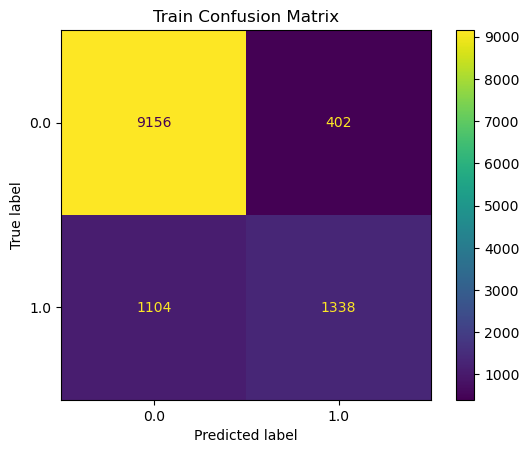

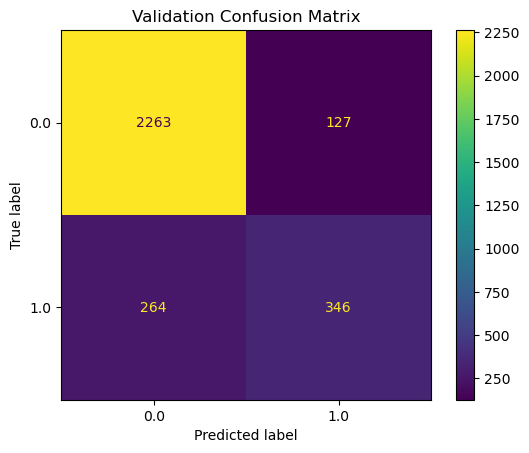

In [21]:
# Confusion matrix plots
ConfusionMatrixDisplay.from_predictions(train_targets, train_preds)
plt.title("Train Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(val_targets, val_preds)
plt.title("Validation Confusion Matrix")
plt.show()

In [22]:
# ROC Curve
train_fpr, train_tpr, _ = roc_curve(train_targets, train_probs)
val_fpr, val_tpr, _ = roc_curve(val_targets, val_probs)

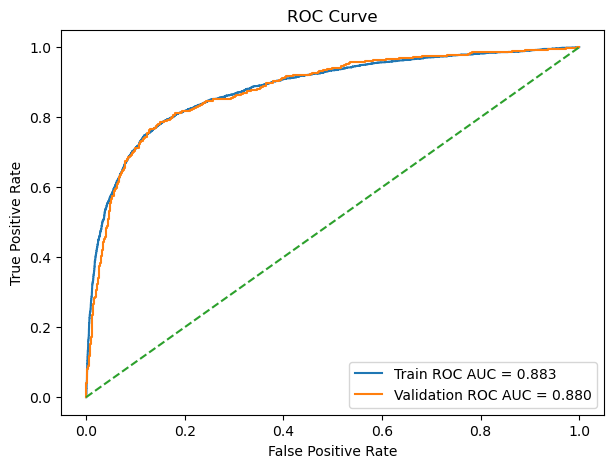

In [23]:
plt.figure(figsize=(7, 5))
plt.plot(train_fpr, train_tpr, label=f"Train ROC AUC = {train_auc:.3f}")
plt.plot(val_fpr, val_tpr, label=f"Validation ROC AUC = {val_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Модель показала схожі результати на тренувальних та валідаційних даних: `Train AUROC ≈ 0.883`, `Validation AUROC ≈ 0.880`, `Train F1 ≈ 0.640`, `Validation F1 ≈ 0.639`. Модель не має явного перенавчання, оскільки якість на train і validation майже однакова. Я би оцінила якість моделі як здовільну. Але confusion matrix показує, що модель ще пропускає частину клієнтів, які реально пішли з банку.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [24]:
from sklearn.metrics import accuracy_score

# Мажоритарний клас у train
majority_class = train_targets.mode()[0]

# Baseline: завжди передбачає мажоритарний клас
train_majority_preds = np.full_like(train_targets, fill_value=majority_class)
val_majority_preds = np.full_like(val_targets, fill_value=majority_class)

# Accuracy baseline-моделі
train_majority_acc = accuracy_score(train_targets, train_majority_preds)
val_majority_acc = accuracy_score(val_targets, val_majority_preds)

# Accuracy нашої LogisticRegression моделі
train_model_acc = accuracy_score(train_targets, train_preds)
val_model_acc = accuracy_score(val_targets, val_preds)

print("Majority class:", majority_class)

print("\nBaseline Train Accuracy:", train_majority_acc)
print("Baseline Validation Accuracy:", val_majority_acc)

print("\nLogistic Regression Train Accuracy:", train_model_acc)
print("Logistic Regression Validation Accuracy:", val_model_acc)

Majority class: 0.0

Baseline Train Accuracy: 0.7965
Baseline Validation Accuracy: 0.7966666666666666

Logistic Regression Train Accuracy: 0.8745
Logistic Regression Validation Accuracy: 0.8696666666666667


 Наша модельпоказала кращий результат: `Validation Accuracy ≈ 0.870`, тому її якість можна оцінити як кращу за baseline і загалом задовільну для базової моделі.


9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [25]:
import joblib

# Зберігаємо модель у файл
joblib.dump(model, 'log_reg.joblib')

# Завантажуємо модель з файлу
model_2 = joblib.load('log_reg.joblib')

model_2

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [28]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    input_df = input_df.copy()
    
    # заповнюємо пропущені значення в числових колонках
    input_df[numeric_cols] = num_imputer.transform(input_df[numeric_cols])
    
    # масштабуємо числові колонки
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    
    # кодуємо категоріальні колонки
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    
    # беремо тільки ті колонки, які йдуть в модель
    X_input = input_df[numeric_cols + list(encoded_cols)]
    
    # передбачаємо ймовірність класу 1
    prob = model_2.predict_proba(X_input)[:, 1]
    
    return prob

In [29]:
raw_df = train_df.drop(columns=[target_col])

predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, raw_df[:5])

array([0.00564915, 0.03331584, 0.38132823, 0.38028102, 0.97920024])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [30]:
test_raw_df = pd.read_csv('test.csv')

test_raw_df['Exited'] = predict_raw_df(
    scaler,
    encoder,
    numeric_cols,
    categorical_cols,
    test_raw_df
)

test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.069305
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.033363
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.153864
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.198330
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.054045


In [31]:
submission_df = test_raw_df[['id', 'Exited']]

submission_df.head()

,id,Exited
0,15000,0.069305
1,15001,0.033363
2,15002,0.153864
3,15003,0.198330
4,15004,0.054045


In [32]:
submission_df.to_csv("submission.csv", index=False)

submission_df.head()

,id,Exited
0,15000,0.069305
1,15001,0.033363
2,15002,0.153864
3,15003,0.198330
4,15004,0.054045


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [33]:
sample_submission = pd.read_csv('sample_submission.csv')

sample_submission['Exited'] = test_raw_df['Exited']

sample_submission.head()

,id,Exited
0,15000,0.069305
1,15001,0.033363
2,15002,0.153864
3,15003,0.198330
4,15004,0.054045


In [34]:
sample_submission.to_csv('submission_log_reg.csv', index=False)

In [35]:
pd.read_csv('submission_log_reg.csv').head()

,id,Exited
0,15000,0.069305
1,15001,0.033363
2,15002,0.153864
3,15003,0.198330
4,15004,0.054045
